# Plotting Visium spatial transcriptomics data

This tutorial walks through visualising a real 10x Genomics Visium experiment with `spatialdata-plot`: H&E tissue image, spot polygons, gene expression overlays, and publication-style styling.

**Dataset**: [Human Breast Cancer (Block A Section 1)][10x] from 10x Genomics — fetched once via `scanpy.datasets.visium_sge` and cached by `pooch` for subsequent runs.

**Credit**: the example progression in this tutorial — H&E + spots, gene-expression overlays, outline styling — was originally curated by [@asarigun](https://github.com/asarigun) in [scverse/spatialdata-plot#590](https://github.com/scverse/spatialdata-plot/pull/590).

[10x]: https://www.10xgenomics.com/datasets/human-breast-cancer-block-a-section-1-1-standard-1-1-0

## Loading the dataset

`scanpy.datasets.visium_sge` returns an `AnnData` object with the H&E image, spot coordinates, and per-spot expression. The helper below wraps it as a `SpatialData` object with a `tissue` image, `spots` shapes, and a normalised expression `table`.

In [1]:
import warnings

import numpy as np
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # noqa: F401  (registers the .pl accessor)
from spatialdata.models import Image2DModel, ShapesModel, TableModel


def load_visium_breast_cancer() -> sd.SpatialData:
    """Return the 10x Visium breast-cancer Block A Section 1 as a SpatialData object."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        adata = sc.datasets.visium_sge(sample_id="V1_Breast_Cancer_Block_A_Section_1")

    sample = next(iter(adata.uns["spatial"]))
    meta = adata.uns["spatial"][sample]
    sf = meta["scalefactors"]["tissue_hires_scalef"]

    image = Image2DModel.parse(
        np.moveaxis(meta["images"]["hires"], -1, 0),
        dims=("c", "y", "x"),
    )

    radius = meta["scalefactors"]["spot_diameter_fullres"] * sf / 2
    spots = ShapesModel.parse(
        adata.obsm["spatial"] * sf,
        geometry=0,  # 0 = Point geometry; spatialdata-plot draws them as discs via `radius`
        radius=radius,
        index=adata.obs_names,
    )

    adata.obs["region"] = "spots"
    adata.obs["region"] = adata.obs["region"].astype("category")
    adata.obs["instance_key"] = adata.obs_names
    table = TableModel.parse(
        adata,
        region="spots",
        region_key="region",
        instance_key="instance_key",
    )
    table.var_names_make_unique()
    sc.pp.normalize_total(table)
    sc.pp.log1p(table)

    return sd.SpatialData(
        images={"tissue": image},
        shapes={"spots": spots},
        tables={"table": table},
    )


sdata = load_visium_breast_cancer()
sdata

SpatialData object
├── Images
│     └── 'tissue': DataArray[cyx] (3, 2000, 2000)
├── Shapes
│     └── 'spots': GeoDataFrame shape: (3798, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (3798, 36601)
with coordinate systems:
    ▸ 'global', with elements:
        tissue (Images), spots (Shapes)

## Rendering the tissue image

The H&E image is a standard three-channel RGB image. Rendering it alone gives the histology view.

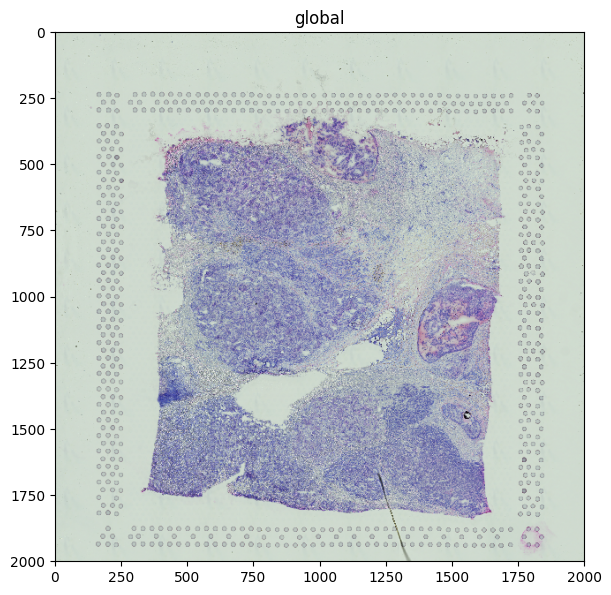

In [2]:
sdata.pl.render_images("tissue").pl.show(figsize=(6, 6))

## Rendering spots on their own

Visium spots are stored as `shapes`. Rendered alone, they show the regular hexagonal capture pattern.

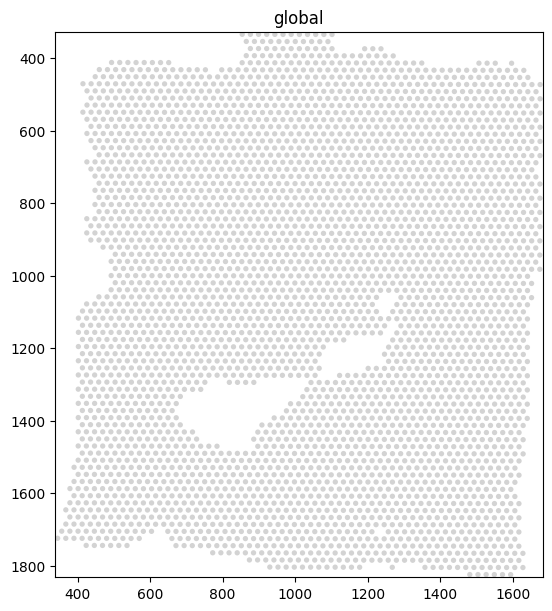

In [3]:
sdata.pl.render_shapes("spots").pl.show(figsize=(6, 6))

## Overlay: tissue + spots

The fluent API chains the two renders. Use `fill_alpha` on the spots so the underlying tissue stays visible.

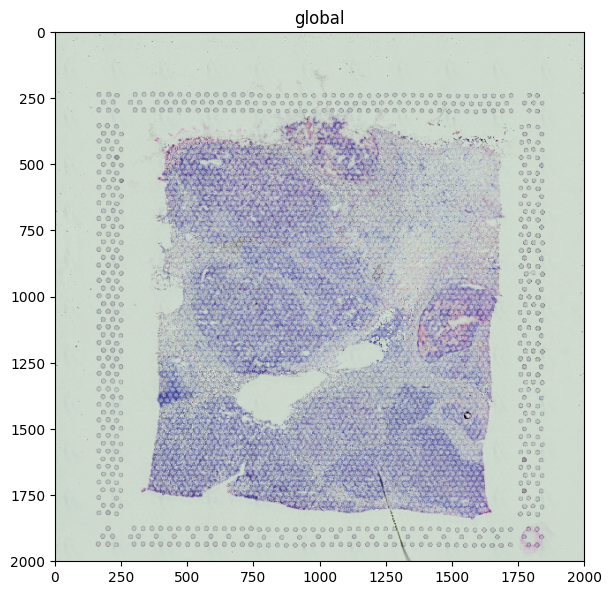

In [4]:
(
    sdata.pl.render_images("tissue")
    .pl.render_shapes("spots", fill_alpha=0.5)
    .pl.show(figsize=(6, 6))
)

## Coloring spots by gene expression

Pass `color=<gene>` to map a column from the linked table onto the spot fill. `ERBB2` (HER2) is a well-known breast-cancer marker; the expression pattern aligns with the tumour-rich regions of this section.

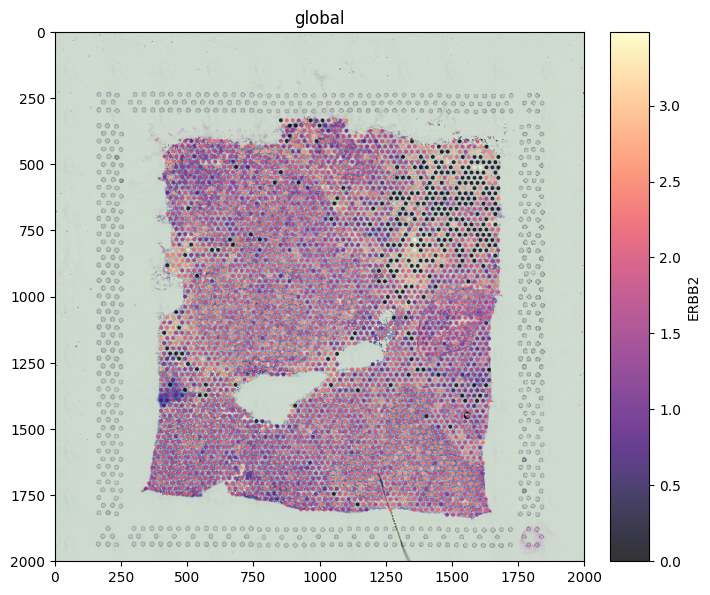

In [5]:
(
    sdata.pl.render_images("tissue")
    .pl.render_shapes("spots", color="ERBB2", cmap="magma", fill_alpha=0.8)
    .pl.show(figsize=(6, 6))
)

## Coloring spots by a category

`color=` also accepts categorical columns — here, the `in_tissue` flag 10x sets to mark spots that fall on tissue.

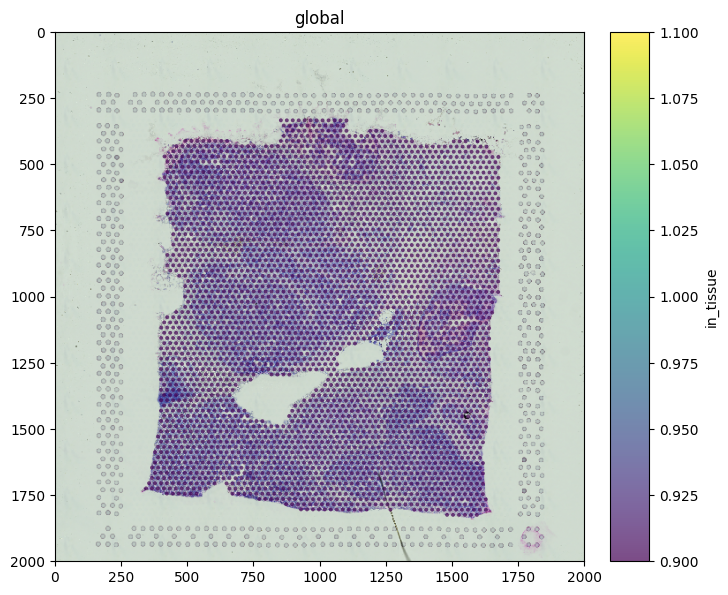

In [6]:
(
    sdata.pl.render_images("tissue")
    .pl.render_shapes("spots", color="in_tissue", fill_alpha=0.7)
    .pl.show(figsize=(6, 6))
)

## Publication-style styling

For a polished figure: keep the tissue context, color the spots by expression with a perceptually uniform colormap, draw a thin white outline to make the spots pop against the H&E, and use a translucent fill so the histology underneath remains readable.

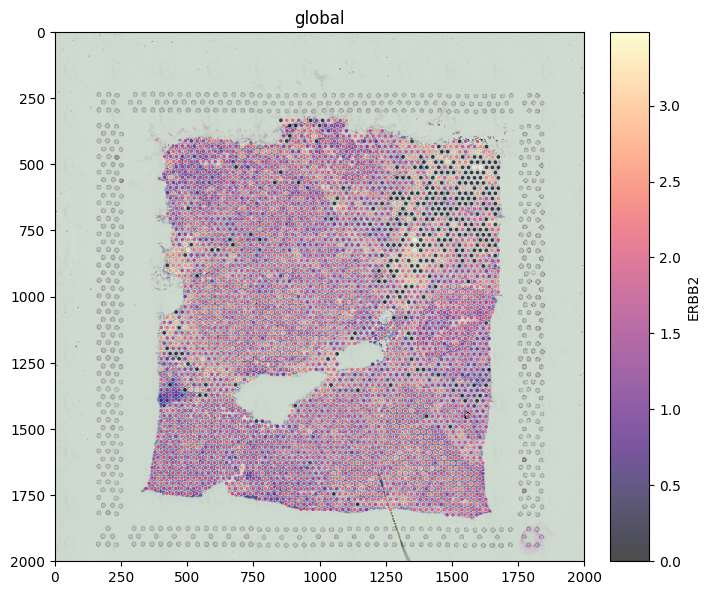

In [7]:
(
    sdata.pl.render_images("tissue")
    .pl.render_shapes(
        "spots",
        color="ERBB2",
        cmap="magma",
        fill_alpha=0.7,
        outline_width=0.4,
        outline_color="white",
        outline_alpha=1.0,
    )
    .pl.show(figsize=(6, 6))
)

## Where to next

- **API reference** — every parameter of `render_shapes`, `render_images`, and `show()` is documented in the [plotting API](https://spatialdata.scverse.org/projects/plot/en/latest/api.html).
- **Getting started tutorial** — if you skipped it, the [Getting started](./getting_started.ipynb) tutorial covers the same fluent API on the lightweight built-in `blobs` dataset.
- **Contributing** — found a missing example? Open a PR on [`spatialdata-plot-notebooks`](https://github.com/scverse/spatialdata-plot-notebooks).